# RAG for NVIDIA NVDocs

**Pipeline:**
1. EDA
2. Data Preparation
3. Retrieval Indexes (BM25 + TF-IDF)
4. Feature Engineering
5. Train Ranking Models (Decision Tree, Random Forest, XGBoost, LightGBM)
6. Evaluation & Comparison
7. End-to-End RAG Demo

## Stage 0: Setup & Install Dependencies

In [85]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [86]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

## Stage 1: EDA

In [3]:
from datasets import load_dataset

dataset = load_dataset("nvidia/Retrieval-Synthetic-NVDocs-v1")
print(dataset)

c:\Users\sidagarwal\OneDrive - Microsoft\Documents\GitHub\Applied-Machine-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 15095
    })
})


In [4]:
display(dataset['train'][0])

{'file_name': ['researchnvidiacom/research.nvidia.com_publication_2022-11_demystifying-map-space-exploration-npus'],
 'text': 'Map Space Exploration is the problem of finding optimized mappings of a Deep Neural Network (DNN) model on an accelerator. It is known to be extremely computationally expensive, and there has been active research looking at both heuristics and learning-based methods to make the problem computationally tractable. However, while there are dozens of mappers out there (all empirically claiming to find better mappings than others), the research community lacks systematic insights on how different search techniques navigate the map-space and how different mapping axes contribute to the accelerator’s performance and efficiency. Such insights are crucial to developing mapping frameworks for emerging DNNs that are increasingly irregular (due to neural architecture search) and sparse, making the corresponding map spaces much more complex. In this work, rather than propos

In [5]:
from datasets import DatasetDict

full_dataset = dataset['train']

train_testval = full_dataset.train_test_split(test_size=0.2, seed=42)

In [6]:
#split into validation (10%) and test (10%)
test_val = train_testval['test'].train_test_split(test_size=0.5, seed=42)

In [7]:
split_dataset = DatasetDict({
    'train': train_testval['train'],
    'validation': test_val['train'],
    'test': test_val['test']
})

In [8]:
print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 12076
    })
    validation: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1509
    })
    test: Dataset({
        features: ['file_name', 'text', 'chunks', 'sections_structured', 'bundle_id', 'bundle_members', 'is_multi_doc', 'document_artifacts', 'qa_generation', 'deduplicated_qa_pairs', 'qa_evaluations'],
        num_rows: 1510
    })
})


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = split_dataset['train'].to_pandas()

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12076 entries, 0 to 12075
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   file_name              12076 non-null  object
 1   text                   12076 non-null  str   
 2   chunks                 12076 non-null  object
 3   sections_structured    12076 non-null  object
 4   bundle_id              12076 non-null  str   
 5   bundle_members         12076 non-null  object
 6   is_multi_doc           12076 non-null  bool  
 7   document_artifacts     12076 non-null  object
 8   qa_generation          12076 non-null  object
 9   deduplicated_qa_pairs  12076 non-null  object
 10  qa_evaluations         12076 non-null  object
dtypes: bool(1), object(8), str(2)
memory usage: 59.7+ MB


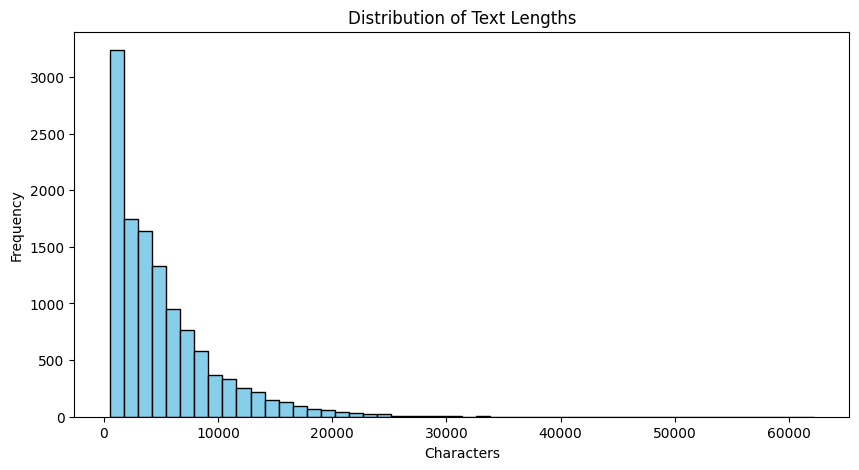

In [11]:
#text length distribution
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Lengths')
plt.xlabel('Characters')
plt.ylabel('Frequency')
plt.show()

In [12]:
#is_multi_doc distribution
if 'is_multi_doc' in df.columns:
    print(df['is_multi_doc'].value_counts())

is_multi_doc
False    12076
Name: count, dtype: int64


### QA-Chunk Mapping

Each document has chunks and QA pairs. Each QA pair's `segment_ids` field maps to its relevant chunks — this is the **golden label** for training.

In [13]:
#inspect a single document
record = split_dataset['train'][0]

print(f"File: {record['file_name']}")
print(f"Number of chunks: {len(record['chunks'])}")
print(f"Number of QA pairs: {len(record['deduplicated_qa_pairs'])}")

File: ['researchnvidiacom/research.nvidia.com_publication_2022-03_gatspi-gpu-accelerated-gate-level-simulation-power-improvement']
Number of chunks: 1
Number of QA pairs: 7


In [14]:
#first QA pair
qa = record['deduplicated_qa_pairs'][0]
print(f"Question: {qa['question']}")
print(f"Answer: {qa['answer'][:200]}...")
print(f"Query Type: {qa['query_type']}")
print(f"Reasoning Type: {qa['reasoning_type']}")
print(f"Complexity: {qa['question_complexity']}")
print(f"Hop Count: {qa['hop_count']}")
print(f"Relevant Segment IDs: {qa['segment_ids']}")

Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators, and what role do custom CUDA kernels play in this process?
Answer: GATSPI leverages GPU acceleration through custom CUDA kernels in PyTorch, enabling a simulation kernel speedup of up to 1668X on a single-GPU system and 7412X on multiple-GPU systems compared to comme...
Query Type: multi_hop
Reasoning Type: factual
Complexity: 5
Hop Count: 1
Relevant Segment IDs: [1]


In [15]:
#preview relevant chunks
chunk_lookup = {c['chunk_id']: c for c in record['chunks']}
for sid in qa['segment_ids']:
    if sid in chunk_lookup:
        c = chunk_lookup[sid]
        print(f"\nChunk ID: {sid}")
        print(f"Text preview: {c['text'][:300]}...")
        print(f"Word count: {c['word_count']}, Sentence count: {c['sentence_count']}")


Chunk ID: 1
Text preview: In this paper, we present GATSPI, a novel GPU accelerated logic gate simulator that enables ultra-fast power estimation for industry sized ASIC designs with millions of gates.. GATSPI is written in PyTorch with custom CUDA kernels for ease of coding and maintainability.. It achieves simulation kerne...
Word count: 140, Sentence count: 5


## Stage 2: Data Preparation

I extract all chunks and QA pairs, then create training triples:
- **Positive**: (question, relevant_chunk, 1) — chunk is in `segment_ids`
- **Negative**: (question, random_chunk, 0) — sampled from other chunks

Note: Random negatives led to subpar NDCG@10 (matching BM25 raw ranking). I later replaced them with BM25∪TF-IDF top-100 candidate pools (hard negatives) in Stage 5 for actual model training.

In [16]:
from data_prep import extract_all_chunks, extract_qa_pairs, create_relevance_triples, build_chunk_lookup

train_chunks, next_chunk_off, next_doc_off = extract_all_chunks(split_dataset['train'], chunk_offset=0, doc_offset=0)
print(f"Train: {len(train_chunks)} chunks")

Extracting chunks: 100%|██████████| 12076/12076 [00:48<00:00, 247.63it/s]

Train: 96442 chunks


In [17]:
val_chunks, next_chunk_off, next_doc_off = extract_all_chunks(split_dataset['validation'], chunk_offset=next_chunk_off, doc_offset=next_doc_off)
print(f"Val: {len(val_chunks)} chunks")

Extracting chunks: 100%|██████████| 1509/1509 [00:06<00:00, 237.04it/s]

Val: 12274 chunks


In [18]:
test_chunks, next_chunk_off, next_doc_off = extract_all_chunks(split_dataset['test'], chunk_offset=next_chunk_off, doc_offset=next_doc_off)
print(f"Test: {len(test_chunks)} chunks")

Extracting chunks: 100%|██████████| 1510/1510 [00:06<00:00, 247.97it/s]

Test: 12162 chunks


In [19]:
all_chunks = train_chunks + val_chunks + test_chunks
chunk_by_id, chunk_by_doc_original = build_chunk_lookup(all_chunks)
print(f"Total chunks in corpus: {len(all_chunks)}")
print(f"Unique chunk IDs: {len(chunk_by_id)}, lookup entries: {len(chunk_by_doc_original)}")

Total chunks in corpus: 120878
Unique chunk IDs: 120878, lookup entries: 120878


In [20]:
#extract QA pairs (needs chunk lookup for ID mapping)
train_qa = extract_qa_pairs(split_dataset['train'], chunk_by_doc_original, doc_offset=0)
val_qa = extract_qa_pairs(split_dataset['validation'], chunk_by_doc_original, doc_offset=len(split_dataset['train']))
test_qa = extract_qa_pairs(split_dataset['test'], chunk_by_doc_original, doc_offset=len(split_dataset['train']) + len(split_dataset['validation']))
print(f"QA pairs: train={len(train_qa)}, val={len(val_qa)}, test={len(test_qa)}")

train_triples = create_relevance_triples(train_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Train triples: {len(train_triples)} ({train_triples['relevance'].sum()} pos, {(train_triples['relevance']==0).sum()} neg)")

Extracting QA pairs:   0%|          | 0/12076 [00:00<?, ?it/s]

Extracting QA pairs: 100%|██████████| 1510/1510 [00:05<00:00, 256.35it/s]


QA pairs: train=84485, val=10560, test=10561


Creating triples: 100%|██████████| 84485/84485 [00:04<00:00, 21099.50it/s]


Train triples: 959805 (191961 pos, 767844 neg)


In [21]:
val_triples = create_relevance_triples(val_qa, all_chunks, neg_per_positive=4, seed=42)
print(f"Val triples: {len(val_triples)} ({val_triples['relevance'].sum()} pos, {(val_triples['relevance']==0).sum()} neg)")

Creating triples: 100%|██████████| 10560/10560 [00:00<00:00, 20029.18it/s]


Val triples: 120950 (24190 pos, 96760 neg)


### Sanity Checks

In [22]:
chunk_lookup_all = chunk_by_id

#verify no duplicate chunk IDs
all_ids = [c['chunk_id'] for c in all_chunks]
assert len(all_ids) == len(set(all_ids)), f"DUPLICATE chunk IDs! {len(all_ids)} total vs {len(set(all_ids))} unique"
print(f"✓ All {len(all_ids)} chunk IDs are globally unique")

✓ All 120878 chunk IDs are globally unique


In [23]:
#golden chunk_id coverage
for split_name, qa_list in [('train', train_qa), ('val', val_qa), ('test', test_qa)]:
    missing = 0
    total = 0
    for qa in qa_list:
        for cid in qa['chunk_ids']:
            total += 1
            if cid not in chunk_by_id:
                missing += 1
    pct = missing / total * 100 if total > 0 else 0
    if missing == 0:
        print(f"✓ {split_name}: all {total} golden chunk_ids found")
    else:
        print(f"⚠ {split_name}: {missing}/{total} ({pct:.2f}%) chunk_ids missing (dataset noise, skipped)")

✓ train: all 191966 golden chunk_ids found
✓ val: all 24190 golden chunk_ids found
✓ test: all 24230 golden chunk_ids found


In [24]:
#verify positive triples have correct chunk text
for split_name, triples in [('train', train_triples), ('val', val_triples)]:
    pos_triples = triples[triples['relevance'] == 1]
    bad = 0
    for _, row in pos_triples.iterrows():
        if row['chunk_id'] not in chunk_lookup_all:
            bad += 1
            continue
        actual_text = chunk_lookup_all[row['chunk_id']]['chunk_text']
        if actual_text != row['chunk_text']:
            bad += 1
    assert bad == 0, f"{split_name}: {bad} positive triples have mismatched chunk text!"
    print(f"✓ {split_name}: all {len(pos_triples)} positive triples correct")

✓ train: all 191961 positive triples correct
✓ val: all 24190 positive triples correct


In [25]:
#verify no doc_id overlap between splits
train_docs = set(c['doc_id'] for c in train_chunks)
val_docs = set(c['doc_id'] for c in val_chunks)
test_docs = set(c['doc_id'] for c in test_chunks)
assert not (train_docs & val_docs), f"Train/Val overlap: {train_docs & val_docs}"
assert not (train_docs & test_docs), f"Train/Test overlap: {train_docs & test_docs}"
assert not (val_docs & test_docs), f"Val/Test overlap: {val_docs & test_docs}"
print(f"✓ No doc_id overlap: train={len(train_docs)}, val={len(val_docs)}, test={len(test_docs)}")

✓ No doc_id overlap: train=12076, val=1509, test=1510


In [26]:
#sample positive triple
sample_pos = train_triples[train_triples['relevance'] == 1].iloc[0]
print(f"\n── Sample positive triple ──")
print(f"  Question: {sample_pos['question'][:120]}...")
print(f"  Chunk ID: {sample_pos['chunk_id']}")
print(f"  Chunk text: {sample_pos['chunk_text'][:120]}...")
print(f"  Relevance: {sample_pos['relevance']}")


── Sample positive triple ──
  Question: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators,...
  Chunk ID: 0
  Chunk text: In this paper, we present GATSPI, a novel GPU accelerated logic gate simulator that enables ultra-fast power estimation ...
  Relevance: 1


In [27]:
#label balance
for split_name, triples in [('train', train_triples), ('val', val_triples)]:
    n_pos = (triples['relevance'] == 1).sum()
    n_neg = (triples['relevance'] == 0).sum()
    ratio = n_neg / n_pos if n_pos > 0 else float('inf')
    print(f"  {split_name}: {n_pos} positive, {n_neg} negative (ratio ~{ratio:.1f}:1)")

  train: 191961 positive, 767844 negative (ratio ~4.0:1)
  val: 24190 positive, 96760 negative (ratio ~4.0:1)


~332 golden segment_ids (out of ~192k chunks) don't resolve to a chunk in the corpus. I skip these during training.

## Stage 3: Build Retrieval Indexes

I build two indexes over the **entire corpus**:

1. **BM25** — sparse lexical scoring based on token overlap
2. **TF-IDF** — TfidfVectorizer + cosine similarity for term importance

These scores become features for the ranking models.

In [28]:
from retrieval import BM25Index, TfidfIndex

corpus_texts = [c['chunk_text'] for c in all_chunks]
corpus_ids = [c['chunk_id'] for c in all_chunks]
print(f"Corpus size: {len(corpus_texts)} chunks")

Corpus size: 120878 chunks


In [29]:
bm25_index = BM25Index(corpus_texts, corpus_ids)

BM25 index built: 120878 docs, 110482 terms (sparse matrix)


In [30]:
tfidf_index = TfidfIndex(max_features=20000, ngram_range=(1, 2))
tfidf_index.build_index(corpus_texts, corpus_ids)

Building TF-IDF index over 120878 chunks...
TF-IDF index built: 120878 docs, 20000 features


In [31]:
#test retrieval
sample_q = train_qa[0]['question']
print(f"Query: {sample_q}\n")

print("BM25 top-5:")
for chunk_id, score in bm25_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: {score:.4f}")

print("\nTF-IDF top-5:")
for chunk_id, score in tfidf_index.top_k(sample_q, k=5):
    print(f"  {chunk_id}: {score:.4f}")

golden_ids = set(train_qa[0]['chunk_ids'])
print(f"\nGolden chunk IDs: {golden_ids}")

Query: How does the utilization of GPU acceleration in GATSPI contribute to its significant speedup over commercial simulators, and what role do custom CUDA kernels play in this process?

BM25 top-5:
  0: 45.2301
  65361: 32.4650
  23866: 29.3795
  41458: 28.2134
  2374: 28.1439

TF-IDF top-5:
  24428: 0.2955
  113174: 0.2335
  64689: 0.2183
  38521: 0.2177
  52777: 0.2155

Golden chunk IDs: {0}


## Stage 4: Feature Engineering

For each (question, chunk) pair, I compute:

| Feature | Source |
|---------|--------|
| `bm25_score` | BM25 index |
| `cosine_similarity` | TF-IDF cosine similarity |
| `token_overlap_ratio` | Token set overlap |
| `token_overlap_count` | Token set overlap |
| `question_length` | Question metadata |
| `chunk_word_count` | Chunk metadata |
| `chunk_sentence_count` | Chunk metadata |
| `question_complexity` | QA metadata |
| `hop_count` | QA metadata |
| `qtype_*` | One-hot query type |
| `rtype_*` | One-hot reasoning type |

I use these features (minus low-importance qtype/rtype) to train the ranking models.

In [32]:
import gc; gc.collect()
from features import compute_features, get_feature_columns

#subsample train triples to 10k questions for faster feature computation
FEAT_SAMPLE = 10000
rng_feat = np.random.RandomState(42)
_unique_q = train_triples['question'].unique()
if len(_unique_q) > FEAT_SAMPLE:
    _sampled_q = set(rng_feat.choice(_unique_q, FEAT_SAMPLE, replace=False))
    train_triples_sampled = train_triples[train_triples['question'].isin(_sampled_q)].reset_index(drop=True)
    print(f"Subsampled train triples: {len(train_triples):,} → {len(train_triples_sampled):,} ({FEAT_SAMPLE} questions)")
else:
    train_triples_sampled = train_triples

train_featured = compute_features(train_triples_sampled, bm25_index, tfidf_index)
del train_triples_sampled; gc.collect()
print(f"\nTrain shape: {train_featured.shape}")

Subsampled train triples: 959,805 → 113,405 (10000 questions)
Computing features for 113,405 pairs (10,000 unique questions)...
BM25 scoring (sparse pair-wise, batched)...
  BM25 0/113,405...
  BM25 done: (113405,)
TF-IDF scoring (sparse pair-wise, batched)...
  TF-IDF 0/113,405...
  TF-IDF done: (113405,)
Computing text overlap features...
  overlap 0/113,405...
  overlap done
Computing rank features...
  rank features done

Train shape: (113405, 30)


In [33]:
feature_cols = get_feature_columns(train_featured)
print(f"Feature columns ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  - {col}")

train_featured[feature_cols].describe().round(3)

Feature columns (23):
  - question_complexity
  - hop_count
  - chunk_word_count
  - chunk_sentence_count
  - bm25_score
  - cosine_similarity
  - token_overlap_ratio
  - token_overlap_count
  - question_length
  - bm25_rank
  - tfidf_rank
  - bm25_reciprocal_rank
  - rank_diff
  - qtype_contextual
  - qtype_multi_hop
  - qtype_structural
  - rtype_causal
  - rtype_factual
  - rtype_inferential
  - rtype_procedural
  - rtype_relational
  - rtype_temporal
  - rtype_visual


,question_complexity,hop_count,chunk_word_count,chunk_sentence_count,bm25_score,cosine_similarity,token_overlap_ratio,token_overlap_count,question_length,bm25_rank,tfidf_rank,bm25_reciprocal_rank,rank_diff
count,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000,113405.000
mean,4.915,1.812,96.936,4.755,10.184,0.044,0.210,4.969,26.897,7.192,7.192,0.262,0.000
std,0.278,0.913,58.519,0.814,13.651,0.091,0.112,2.778,5.862,5.293,5.293,0.260,2.683
min,4.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,10.000,1.000,1.000,0.008,-63.000
25%,5.000,1.000,67.000,5.000,2.564,0.000,0.143,3.000,23.000,3.000,3.000,0.100,-1.000
50%,5.000,1.000,95.000,5.000,5.050,0.005,0.200,5.000,27.000,6.000,6.000,0.167,0.000
75%,5.000,3.000,120.000,5.000,10.021,0.029,0.263,6.000,31.000,10.000,10.000,0.333,1.000
max,5.000,5.000,4964.000,5.000,124.605,0.850,0.824,23.000,56.000,125.000,125.000,1.000,45.000


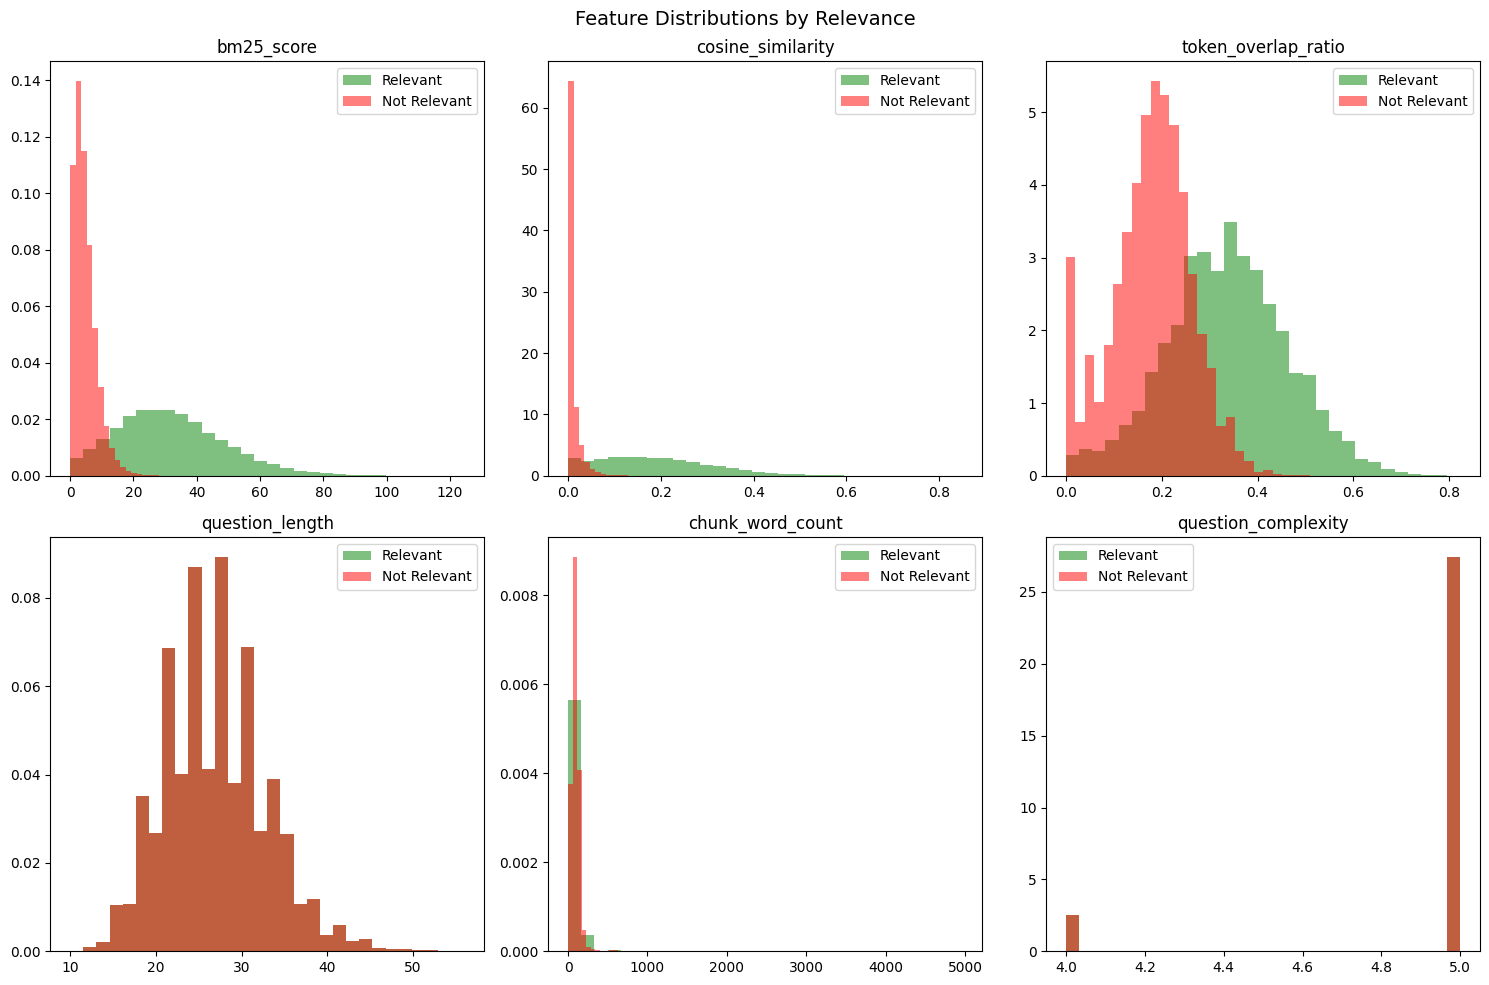

In [34]:
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
key_features = ['bm25_score', 'cosine_similarity', 'token_overlap_ratio',
                'question_length', 'chunk_word_count', 'question_complexity']

for ax, feat in zip(axes.flat, key_features):
    for rel, color, label in [(1, 'green', 'Relevant'), (0, 'red', 'Not Relevant')]:
        subset = train_featured[train_featured['relevance'] == rel][feat]
        ax.hist(subset, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Feature Distributions by Relevance', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier as _RFC

#quick RF for feature importance
_rf_importance = _RFC(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
_rf_importance.fit(train_featured[feature_cols].values, train_featured['relevance'].values)

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': _rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:\n")
print(importance_df.to_string(index=False))

Feature Importance:

             feature  importance
   cosine_similarity    0.300484
          bm25_score    0.262873
          tfidf_rank    0.127438
bm25_reciprocal_rank    0.120566
           bm25_rank    0.094456
 token_overlap_ratio    0.045561
 token_overlap_count    0.016807
           rank_diff    0.010576
           hop_count    0.006085
    chunk_word_count    0.005242
     question_length    0.003945
chunk_sentence_count    0.001156
     qtype_multi_hop    0.000933
 question_complexity    0.000681
    qtype_contextual    0.000483
    qtype_structural    0.000433
    rtype_relational    0.000363
        rtype_causal    0.000360
    rtype_procedural    0.000354
   rtype_inferential    0.000352
      rtype_temporal    0.000312
       rtype_factual    0.000306
        rtype_visual    0.000234


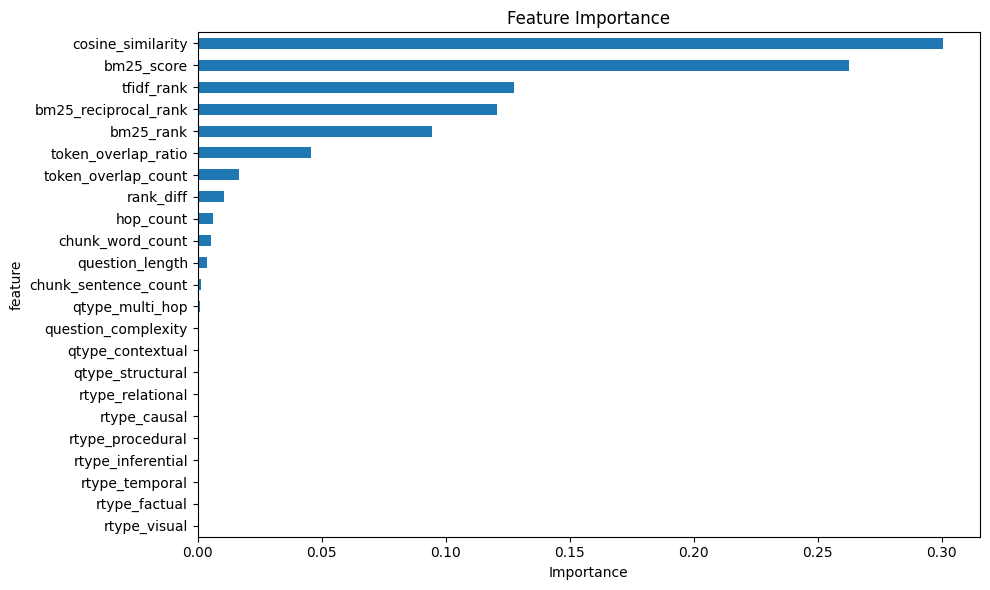

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
importance_df.plot(x='feature', y='importance', kind='barh', ax=ax, legend=False)
ax.invert_yaxis()
ax.set_title('Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [37]:
#low-importance features to drop
drop_threshold = 0.01
low_importance = importance_df[importance_df['importance'] < drop_threshold]['feature'].tolist()
print(f"\nFeatures below {drop_threshold} threshold:")
for f in low_importance:
    print(f"  - {f}")


Features below 0.01 threshold:
  - hop_count
  - chunk_word_count
  - question_length
  - chunk_sentence_count
  - qtype_multi_hop
  - question_complexity
  - qtype_contextual
  - qtype_structural
  - rtype_relational
  - rtype_causal
  - rtype_procedural
  - rtype_inferential
  - rtype_temporal
  - rtype_factual
  - rtype_visual


## Stage 5: Train Ranking Models

**Key insight**: Models must train on the **same distribution** they see at evaluation. At eval time, models re-rank BM25∪TF-IDF top-100 candidates (all with high retrieval scores). Training on random negatives (low BM25) causes models to learn a trivial "high BM25 = relevant" rule.

**Solution**: Build training data from candidate pools (hard negatives aka negatives with high BM25 scores)

**Golden chunk injection (training only)**: If a golden chunk is not retrieved in the top-100, we inject it into the training candidate pool so every question has at least one positive label. At evaluation time, no injection is used — the model must work with whatever retrieval returns.

**Models:**
1. **BM25 Baseline** — rank by BM25 score directly
2. **TF-IDF Baseline** — rank by TF-IDF cosine similarity
3. **Decision Tree** — single tree classifier
4. **Random Forest** — ensemble of trees
5. **XGBoost Ranker** — `rank:ndcg` objective
6. **LightGBM Ranker** — LambdaMART

In [38]:
import importlib
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import evaluate as _eval_mod; importlib.reload(_eval_mod)
from evaluate import prepare_candidates, evaluate_from_candidates, candidates_to_training_data, print_evaluation

In [39]:
#drop low-importance qtype/rtype features
drop_features = [c for c in feature_cols if c.startswith('qtype_') or c.startswith('rtype_')]
feature_cols = [c for c in feature_cols if c not in drop_features]
print(f"Dropped {len(drop_features)} features: {drop_features}")
print(f"Keeping {len(feature_cols)}: {feature_cols}")

Dropped 10 features: ['qtype_contextual', 'qtype_multi_hop', 'qtype_structural', 'rtype_causal', 'rtype_factual', 'rtype_inferential', 'rtype_procedural', 'rtype_relational', 'rtype_temporal', 'rtype_visual']
Keeping 13: ['question_complexity', 'hop_count', 'chunk_word_count', 'chunk_sentence_count', 'bm25_score', 'cosine_similarity', 'token_overlap_ratio', 'token_overlap_count', 'question_length', 'bm25_rank', 'tfidf_rank', 'bm25_reciprocal_rank', 'rank_diff']


Our original approach was to take the training questions and score them against all the chunks. This got to be a large compute/memory problem quick --> 82k questions x 192k chunks = ~10B entries...

I tried a few different approaches with batching, however none really worked. In the end, I decided to go with subsampling the training data and taking 10k samples. 

In an ideal world, and when implementing this in production I would want to explore a few approaches:
1. Having an inverted index so we can have a small set of candidates docs in training that match between query-document
2. Using OAI, Cohere text embeddings to map the chunks in a vector space. Then we would be able to map the user query in a vector space, then finding the closest top neighbors / results / chunks

In [40]:
chunk_lookup = chunk_by_id

#subsample training questions for faster candidate computation
TRAIN_SAMPLE_SIZE = 10000
rng = np.random.RandomState(42)
if len(train_qa) > TRAIN_SAMPLE_SIZE:
    train_qa_sample = [train_qa[i] for i in rng.choice(len(train_qa), TRAIN_SAMPLE_SIZE, replace=False)]
    print(f"Subsampled train_qa: {len(train_qa)} → {len(train_qa_sample)}")
else:
    train_qa_sample = train_qa

Subsampled train_qa: 84485 → 10000


In [41]:
#precompute train candidates
print("Building train candidate pools (with golden injection)...")
train_candidates = prepare_candidates(train_qa_sample, bm25_index, tfidf_index,
                                       chunk_lookup, feature_cols, candidate_k=100,
                                       inject_golden=True)
n_injected = sum(1 for c in train_candidates if c['metadata']['golden_in_candidates'] == c['metadata']['n_golden'])
print(f"Train: {len(train_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in train_candidates]):.0f} candidates each")
print(f"  100% golden recall (after injection): {n_injected}/{len(train_candidates)} questions")

Building train candidate pools (with golden injection)...
  Encoding 9999 unique questions...
  Scoring 9999 questions in batches of 500...
    500/9999 questions scored
    5500/9999 questions scored


Building features: 100%|██████████| 10000/10000 [02:14<00:00, 74.38it/s]


Train: 10000 questions, avg 155 candidates each
  100% golden recall (after injection): 10000/10000 questions


In [42]:
#precompute val candidates
print("\nBuilding val candidate pools (no injection)...")
val_candidates = prepare_candidates(val_qa, bm25_index, tfidf_index,
                                     chunk_lookup, feature_cols, candidate_k=100)
print(f"Val: {len(val_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in val_candidates]):.0f} candidates each")


Building val candidate pools (no injection)...
  Encoding 10560 unique questions...
  Scoring 10560 questions in batches of 500...
    500/10560 questions scored
    5500/10560 questions scored
    10500/10560 questions scored


Building features: 100%|██████████| 10560/10560 [02:13<00:00, 78.93it/s]

Val: 10560 questions, avg 154 candidates each


### 5a. Training Data from Candidates & Baselines

In [43]:
#convert candidates to training arrays
X_train, y_train, train_groups = candidates_to_training_data(train_candidates, feature_cols)
X_val, y_val, val_groups = candidates_to_training_data(val_candidates, feature_cols)

print(f"Training: X={X_train.shape}, pos={y_train.sum():.0f}, neg={(y_train==0).sum():.0f}")
print(f"Validation: X={X_val.shape}, pos={y_val.sum():.0f}, neg={(y_val==0).sum():.0f}")
print(f"Train groups: {len(train_groups)}, avg size: {train_groups.mean():.0f}")
print(f"Val groups: {len(val_groups)}, avg size: {val_groups.mean():.0f}")

Training: X=(1545316, 13), pos=22780, neg=1522536
Validation: X=(1621823, 13), pos=17500, neg=1604323
Train groups: 10000, avg size: 155
Val groups: 10560, avg size: 154


In [44]:
#BM25 baseline
bm25_val_metrics, _ = evaluate_from_candidates(val_candidates, model=None)
print_evaluation(bm25_val_metrics, "BM25 Baseline (Val)")

#TF-IDF baseline
tfidf_val_metrics, _ = evaluate_from_candidates(val_candidates, model='tfidf')
print_evaluation(tfidf_val_metrics, "TF-IDF Baseline (Val)")

Evaluating: 100%|██████████| 10560/10560 [00:03<00:00, 2824.12it/s]



  BM25 Baseline (Val) Evaluation Results
  MAP            : 0.4699
  MRR            : 0.5694
  NDCG@10        : 0.5290
  NDCG@20        : 0.5529
  NDCG@5         : 0.4944
  Recall@10      : 0.5367
  Recall@20      : 0.5997
  Recall@5       : 0.4631


Evaluating: 100%|██████████| 10560/10560 [00:03<00:00, 3282.42it/s]


  TF-IDF Baseline (Val) Evaluation Results
  MAP            : 0.2978
  MRR            : 0.3821
  NDCG@10        : 0.3487
  NDCG@20        : 0.3777
  NDCG@5         : 0.3124
  Recall@10      : 0.3897
  Recall@20      : 0.4684
  Recall@5       : 0.3109


### 5b. Decision Tree Classifier

In [45]:
dt_model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [46]:
dt_val_metrics, _ = evaluate_from_candidates(val_candidates, dt_model)
print_evaluation(dt_val_metrics, "Decision Tree (Val)")

dt_importance = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(dt_importance.head(10))

Evaluating: 100%|██████████| 10560/10560 [00:04<00:00, 2376.12it/s]


  Decision Tree (Val) Evaluation Results
  MAP            : 0.4529
  MRR            : 0.5552
  NDCG@10        : 0.5135
  NDCG@20        : 0.5292
  NDCG@5         : 0.4815
  Recall@10      : 0.5216
  Recall@20      : 0.5629
  Recall@5       : 0.4536
bm25_reciprocal_rank    0.559452
bm25_rank               0.145389
bm25_score              0.133107
cosine_similarity       0.067663
tfidf_rank              0.045502
rank_diff               0.012209
chunk_word_count        0.012077
token_overlap_ratio     0.009718
question_length         0.006270
hop_count               0.003682
dtype: float64


### 5c. Random Forest Classifier

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [48]:
rf_val_metrics, _ = evaluate_from_candidates(val_candidates, rf_model)
print_evaluation(rf_val_metrics, "Random Forest (Val)")

rf_importance = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(rf_importance.head(10))

Evaluating: 100%|██████████| 10560/10560 [00:22<00:00, 471.09it/s] 



  Random Forest (Val) Evaluation Results
  MAP            : 0.4738
  MRR            : 0.5719
  NDCG@10        : 0.5335
  NDCG@20        : 0.5586
  NDCG@5         : 0.4985
  Recall@10      : 0.5429
  Recall@20      : 0.6087
  Recall@5       : 0.4685
bm25_reciprocal_rank    0.251479
bm25_rank               0.237766
bm25_score              0.129300
tfidf_rank              0.106472
rank_diff               0.096815
cosine_similarity       0.073668
chunk_word_count        0.039110
token_overlap_ratio     0.025972
token_overlap_count     0.015423
question_length         0.013569
dtype: float64


### 5d. XGBoost Ranker

XGBoost `rank:ndcg` directly optimizes NDCG. Requires a `group` parameter for query boundaries.

In [49]:
import xgboost as xgb

print(f"Train groups: {len(train_groups)}, Val groups: {len(val_groups)}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

Train groups: 10000, Val groups: 10560
X_train: (1545316, 13), X_val: (1621823, 13)


In [50]:
xgb_model = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
)

In [51]:
xgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    verbose=50
)

[0]	validation_0-ndcg@32:0.63489
[50]	validation_0-ndcg@32:0.64390
[100]	validation_0-ndcg@32:0.64736
[150]	validation_0-ndcg@32:0.64812
[200]	validation_0-ndcg@32:0.64820
[250]	validation_0-ndcg@32:0.64806
[299]	validation_0-ndcg@32:0.64779


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'rank:ndcg'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sk

In [52]:
xgb_val_metrics, _ = evaluate_from_candidates(val_candidates, xgb_model)
print_evaluation(xgb_val_metrics, "XGBoost Ranker (Val)")

Evaluating: 100%|██████████| 10560/10560 [00:10<00:00, 1002.21it/s]



  XGBoost Ranker (Val) Evaluation Results
  MAP            : 0.4763
  MRR            : 0.5723
  NDCG@10        : 0.5361
  NDCG@20        : 0.5613
  NDCG@5         : 0.4996
  Recall@10      : 0.5463
  Recall@20      : 0.6126
  Recall@5       : 0.4689


### 5e. LightGBM Ranker (LambdaMART)

In [53]:
import lightgbm as lgb

lgb_model = lgb.LGBMRanker(
    objective='lambdarank',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

In [54]:
lgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    eval_at=[5, 10, 20],
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [55]:
lgb_val_metrics, _ = evaluate_from_candidates(val_candidates, lgb_model)
print_evaluation(lgb_val_metrics, "LightGBM Ranker (Val)")

Evaluating:   0%|          | 0/10560 [00:00<?, ?it/s]c:\Users\sidagarwal\OneDrive - Microsoft\Documents\GitHub\Applied-Machine-Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
Evaluating: 100%|██████████| 10560/10560 [00:21<00:00, 497.57it/s] 



  LightGBM Ranker (Val) Evaluation Results
  MAP            : 0.4750
  MRR            : 0.5724
  NDCG@10        : 0.5348
  NDCG@20        : 0.5598
  NDCG@5         : 0.4988
  Recall@10      : 0.5447
  Recall@20      : 0.6104
  Recall@5       : 0.4682


## Stage 9: Hyperparameter Tuning

Grid search over XGBoost and LightGBM (learning_rate × max_depth) with early stopping. Best models are kept in-place — no retraining needed.

In [ ]:
import itertools, time

#grid: 4 combos with early stopping (no retrain needed)
grid = list(itertools.product([0.05, 0.1, 0.2], [4, 6, 8]))
best_xgb_score, best_lgb_score = -1, -1
results = []

for lr, depth in grid:
    t0 = time.time()
    m = xgb.XGBRanker(objective='rank:ndcg', learning_rate=lr, max_depth=depth,
        n_estimators=300, min_child_weight=10, subsample=0.8,
        colsample_bytree=0.8, random_state=42, tree_method='hist',
        verbosity=0, early_stopping_rounds=30)
    m.fit(X_train, y_train, group=train_groups,
          eval_set=[(X_val, y_val)], eval_group=[val_groups], verbose=0)
    xgb_ev = list(m.evals_result()['validation_0'].values())[0][-1]
    if xgb_ev > best_xgb_score:
        best_xgb_score, xgb_model = xgb_ev, m

    m2 = lgb.LGBMRanker(objective='lambdarank', learning_rate=lr, max_depth=depth,
        n_estimators=300, min_child_samples=20, subsample=0.8,
        colsample_bytree=0.8, random_state=42, verbose=-1,
        early_stopping_round=30)
    m2.fit(X_train, y_train, group=train_groups,
           eval_set=[(X_val, y_val)], eval_group=[val_groups], eval_at=[10])
    lgb_ev = list(m2.best_score_['valid_0'].values())[0]
    if lgb_ev > best_lgb_score:
        best_lgb_score, lgb_model = lgb_ev, m2

    results += [('XGBoost', lr, depth, xgb_ev), ('LightGBM', lr, depth, lgb_ev)]
    print(f"lr={lr} depth={depth} → XGB={xgb_ev:.4f} LGB={lgb_ev:.4f}  ({time.time()-t0:.0f}s)")

tuning_df = pd.DataFrame(results, columns=['model','lr','depth','eval_ndcg']).sort_values('eval_ndcg', ascending=False)
print(f"\nTop 5:\n{tuning_df.head(5).to_string(index=False)}")
print(f"\nKept: XGBoost={best_xgb_score:.4f}, LightGBM={best_lgb_score:.4f}")

lr=0.05 depth=4 → XGB=0.6461 LGB=0.6100  (71s)
lr=0.05 depth=6 → XGB=0.6486 LGB=0.6098  (77s)
lr=0.05 depth=8 → XGB=0.6480 LGB=0.6105  (81s)
lr=0.1 depth=4 → XGB=0.6484 LGB=0.6104  (73s)
lr=0.1 depth=6 → XGB=0.6478 LGB=0.6085  (204s)
lr=0.1 depth=8 → XGB=0.6455 LGB=0.6085  (93s)
lr=0.2 depth=4 → XGB=0.6482 LGB=0.6094  (193s)


In [ ]:
#evaluate tuned models (already saved from grid search, no retraining)
xgb_val_metrics, _ = evaluate_from_candidates(val_candidates, xgb_model)
print_evaluation(xgb_val_metrics, "Tuned XGBoost (Val)")

lgb_val_metrics, _ = evaluate_from_candidates(val_candidates, lgb_model)
print_evaluation(lgb_val_metrics, "Tuned LightGBM (Val)")

## Stage 6: Model Comparison & Test Evaluation

I compare all models on validation, pick the best by NDCG@10, then run final evaluation on the held-out test set.

In [56]:
all_val_metrics = {
    'BM25 Baseline': bm25_val_metrics,
    'TF-IDF Cosine': tfidf_val_metrics,
    'Decision Tree': dt_val_metrics,
    'Random Forest': rf_val_metrics,
    'XGBoost Ranker': xgb_val_metrics,
    'LightGBM Ranker': lgb_val_metrics,
}

comparison_df = pd.DataFrame(all_val_metrics).T.round(4)
display(comparison_df)

,NDCG@5,NDCG@10,NDCG@20,Recall@5,Recall@10,Recall@20,MRR,MAP
BM25 Baseline,0.4944,0.5290,0.5529,0.4631,0.5367,0.5997,0.5694,0.4699
TF-IDF Cosine,0.3124,0.3487,0.3777,0.3109,0.3897,0.4684,0.3821,0.2978
Decision Tree,0.4815,0.5135,0.5292,0.4536,0.5216,0.5629,0.5552,0.4529
Random Forest,0.4985,0.5335,0.5586,0.4685,0.5429,0.6087,0.5719,0.4738
XGBoost Ranker,0.4996,0.5361,0.5613,0.4689,0.5463,0.6126,0.5723,0.4763
LightGBM Ranker,0.4988,0.5348,0.5598,0.4682,0.5447,0.6104,0.5724,0.4750


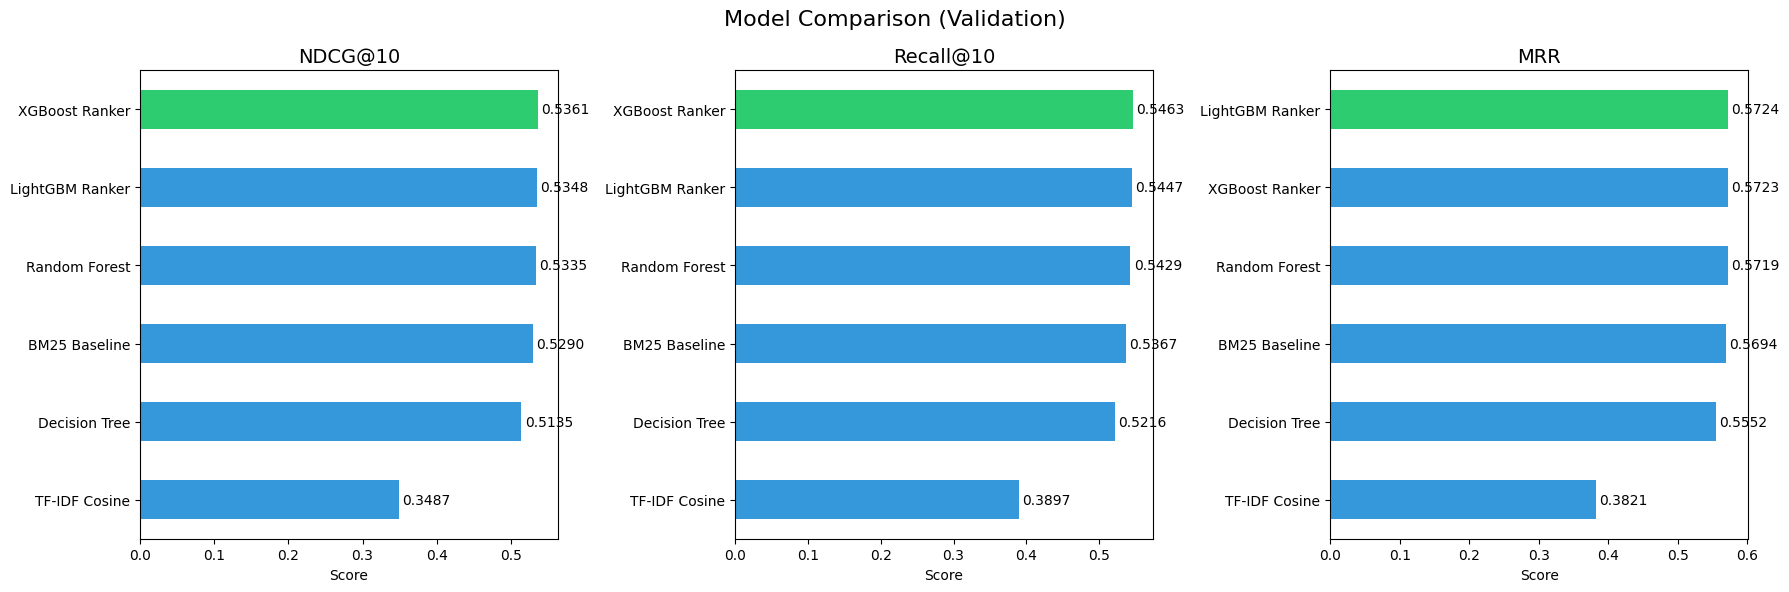

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['NDCG@10', 'Recall@10', 'MRR']
for ax, metric in zip(axes, metrics_to_plot):
    values = comparison_df[metric].sort_values(ascending=True)
    colors = ['#2ecc71' if v == values.max() else '#3498db' for v in values]
    values.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(metric, fontsize=14)
    ax.set_xlabel('Score')
    for i, v in enumerate(values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center')

plt.suptitle('Model Comparison (Validation)', fontsize=16)
plt.tight_layout()
plt.show()

### Final Test Evaluation

For each test question, I retrieve top-100 from BM25 ∪ top-100 from TF-IDF, then re-rank with the best model.

In [58]:
test_candidates = prepare_candidates(test_qa, bm25_index, tfidf_index,
                                      chunk_lookup, feature_cols, candidate_k=100)
print(f"Test: {len(test_candidates)} questions, avg {np.mean([c['metadata']['n_candidates'] for c in test_candidates]):.0f} candidates each")

  Encoding 10561 unique questions...
  Scoring 10561 questions in batches of 500...
    500/10561 questions scored
    5500/10561 questions scored
    10500/10561 questions scored


Building features: 100%|██████████| 10561/10561 [01:46<00:00, 99.46it/s]


Test: 10561 questions, avg 154 candidates each


In [59]:
best_model_name = str(comparison_df['NDCG@10'].idxmax())
print(f"Best model (Val NDCG@10): {best_model_name}")

Best model (Val NDCG@10): XGBoost Ranker


In [60]:
model_objects = {
    'BM25 Baseline': None,
    'TF-IDF Cosine': 'tfidf',
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost Ranker': xgb_model,
    'LightGBM Ranker': lgb_model,
}
best_model_obj = model_objects[best_model_name]

In [61]:
bm25_test_metrics, bm25_meta = evaluate_from_candidates(test_candidates, model=None)
print_evaluation(bm25_test_metrics, "BM25 Baseline (Test)")

Evaluating: 100%|██████████| 10561/10561 [00:03<00:00, 3467.48it/s]



  BM25 Baseline (Test) Evaluation Results
  MAP            : 0.4629
  MRR            : 0.5598
  NDCG@10        : 0.5227
  NDCG@20        : 0.5458
  NDCG@5         : 0.4873
  Recall@10      : 0.5323
  Recall@20      : 0.5935
  Recall@5       : 0.4582


In [62]:
tfidf_test_metrics, tfidf_meta = evaluate_from_candidates(test_candidates, model='tfidf')
print_evaluation(tfidf_test_metrics, "TF-IDF Baseline (Test)")

Evaluating: 100%|██████████| 10561/10561 [00:03<00:00, 3307.42it/s]



  TF-IDF Baseline (Test) Evaluation Results
  MAP            : 0.2992
  MRR            : 0.3807
  NDCG@10        : 0.3494
  NDCG@20        : 0.3780
  NDCG@5         : 0.3138
  Recall@10      : 0.3902
  Recall@20      : 0.4689
  Recall@5       : 0.3120


In [63]:
print(f"Evaluating {best_model_name}...")
best_test_metrics, best_meta = evaluate_from_candidates(test_candidates, best_model_obj)
print_evaluation(best_test_metrics, f"{best_model_name} (Test)")

Evaluating XGBoost Ranker...


Evaluating: 100%|██████████| 10561/10561 [00:05<00:00, 2065.80it/s]



  XGBoost Ranker (Test) Evaluation Results
  MAP            : 0.4703
  MRR            : 0.5650
  NDCG@10        : 0.5308
  NDCG@20        : 0.5552
  NDCG@5         : 0.4944
  Recall@10      : 0.5430
  Recall@20      : 0.6077
  Recall@5       : 0.4667


In [64]:
test_comparison_df = pd.DataFrame({
    'BM25 Baseline': bm25_test_metrics,
    'TF-IDF Cosine': tfidf_test_metrics,
    best_model_name: best_test_metrics,
}).T.round(4)

display(test_comparison_df)

,NDCG@5,NDCG@10,NDCG@20,Recall@5,Recall@10,Recall@20,MRR,MAP
BM25 Baseline,0.4873,0.5227,0.5458,0.4582,0.5323,0.5935,0.5598,0.4629
TF-IDF Cosine,0.3138,0.3494,0.3780,0.3120,0.3902,0.4689,0.3807,0.2992
XGBoost Ranker,0.4944,0.5308,0.5552,0.4667,0.5430,0.6077,0.5650,0.4703


In [65]:
#candidate pool diagnostics
print(f"Avg candidates/question: {best_meta['n_candidates'].mean():.0f}")
print(f"Avg golden chunks/question: {best_meta['n_golden'].mean():.1f}")
print(f"Golden recall in pool: {(best_meta['golden_in_candidates'] / best_meta['n_golden']).mean():.4f}")

Avg candidates/question: 154
Avg golden chunks/question: 2.3
Golden recall in pool: 0.7573


In [66]:
#breakdown by query type
print(f"=== {best_model_name} — By Query Type ===\n")
for qtype in best_meta['query_type'].unique():
    mask = best_meta['query_type'] == qtype
    subset = [c for c, m in zip(test_candidates, mask) if m]
    if len(subset) > 0:
        metrics, _ = evaluate_from_candidates(subset, best_model_obj, k_values=[10])
        print(f"  {qtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

=== XGBoost Ranker — By Query Type ===



Evaluating: 100%|██████████| 4493/4493 [00:01<00:00, 2360.55it/s]


  multi_hop            — NDCG@10: 0.5490, Recall@10: 0.5355, n=4493


Evaluating: 100%|██████████| 3056/3056 [00:01<00:00, 2524.77it/s]


  structural           — NDCG@10: 0.5244, Recall@10: 0.5599, n=3056


Evaluating: 100%|██████████| 3012/3012 [00:01<00:00, 2609.57it/s]

  contextual           — NDCG@10: 0.5100, Recall@10: 0.5370, n=3012


In [67]:
#breakdown by reasoning type
print(f"=== {best_model_name} — By Reasoning Type ===\n")
for rtype in best_meta['reasoning_type'].unique():
    mask = best_meta['reasoning_type'] == rtype
    subset = [c for c, m in zip(test_candidates, mask) if m]
    if len(subset) > 0:
        metrics, _ = evaluate_from_candidates(subset, best_model_obj, k_values=[10])
        print(f"  {rtype:20s} — NDCG@10: {metrics['NDCG@10']:.4f}, Recall@10: {metrics['Recall@10']:.4f}, n={len(subset)}")

=== XGBoost Ranker — By Reasoning Type ===



Evaluating: 100%|██████████| 2263/2263 [00:00<00:00, 2462.06it/s]


  inferential          — NDCG@10: 0.5299, Recall@10: 0.5349, n=2263


Evaluating: 100%|██████████| 2177/2177 [00:00<00:00, 2389.04it/s]


  relational           — NDCG@10: 0.5529, Recall@10: 0.5687, n=2177


Evaluating: 100%|██████████| 2004/2004 [00:00<00:00, 2384.87it/s]


  causal               — NDCG@10: 0.5275, Recall@10: 0.5428, n=2004


Evaluating: 100%|██████████| 1285/1285 [00:00<00:00, 2266.14it/s]


  factual              — NDCG@10: 0.5476, Recall@10: 0.5814, n=1285


Evaluating: 100%|██████████| 1498/1498 [00:00<00:00, 2329.80it/s]


  procedural           — NDCG@10: 0.5087, Recall@10: 0.5119, n=1498


Evaluating: 100%|██████████| 387/387 [00:00<00:00, 2206.85it/s]


  visual               — NDCG@10: 0.5485, Recall@10: 0.5674, n=387


Evaluating: 100%|██████████| 947/947 [00:00<00:00, 2365.29it/s]

  temporal             — NDCG@10: 0.4937, Recall@10: 0.4910, n=947


## Stage 7: End-to-End RAG Demo

Given a question:
1. Retrieve top-50 candidates from BM25 ∪ TF-IDF
2. Compute features for each (question, candidate) pair
3. Re-rank with the best model
4. Return top-5 chunks

In [ ]:
def rag_retrieve(question, tfidf_index, bm25_index, model, feature_cols,
                 candidate_k=50, final_k=5):
    bm25_candidates = dict(bm25_index.top_k(question, k=candidate_k))
    tfidf_candidates = dict(tfidf_index.top_k(question, k=candidate_k))

    #merge candidate sets
    seen = set()
    merged = []
    for cid in list(bm25_candidates.keys()) + list(tfidf_candidates.keys()):
        if cid not in seen:
            seen.add(cid)
            merged.append(cid)

    #baselines: rank by raw score
    if model is None:
        results = [(cid, chunk_lookup[cid]['chunk_text'], bm25_candidates.get(cid, 0.0)) for cid in merged]
        results.sort(key=lambda x: x[2], reverse=True)
        return results[:final_k]
    elif model == 'tfidf':
        results = [(cid, chunk_lookup[cid]['chunk_text'], tfidf_candidates.get(cid, 0.0)) for cid in merged]
        results.sort(key=lambda x: x[2], reverse=True)
        return results[:final_k]

    #build feature matrix
    q_tokens = set(question.lower().split())
    q_len = len(question.split())
    rows = []
    for chunk_id in merged:
        chunk = chunk_lookup[chunk_id]
        c_tokens = set(chunk['chunk_text'].lower().split())
        n_overlap = len(q_tokens & c_tokens) if q_tokens else 0
        row = {
            'bm25_score': bm25_candidates.get(chunk_id, 0.0),
            'cosine_similarity': tfidf_candidates.get(chunk_id, 0.0),
            'token_overlap_ratio': n_overlap / len(q_tokens) if q_tokens else 0.0,
            'token_overlap_count': n_overlap,
            'question_length': q_len,
            'chunk_word_count': chunk['word_count'],
            'chunk_sentence_count': chunk['sentence_count'],
            'question_complexity': 3,
            'hop_count': 1,
        }
        rows.append((chunk_id, chunk['chunk_text'], row))

    feature_rows = pd.DataFrame([r[2] for r in rows])
    #compute rank features
    feature_rows['bm25_rank'] = feature_rows['bm25_score'].rank(ascending=False, method='first').astype(int)
    feature_rows['tfidf_rank'] = feature_rows['cosine_similarity'].rank(ascending=False, method='first').astype(int)
    feature_rows['bm25_reciprocal_rank'] = 1.0 / feature_rows['bm25_rank']
    feature_rows['rank_diff'] = feature_rows['bm25_rank'] - feature_rows['tfidf_rank']
    for col in feature_cols:
        if col not in feature_rows.columns:
            feature_rows[col] = 0
    feature_rows = feature_rows[feature_cols]

    #re-rank
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(feature_rows.values)[:, 1]
    else:
        scores = model.predict(feature_rows.values)

    results = [(rows[i][0], rows[i][1], float(scores[i])) for i in range(len(rows))]
    results.sort(key=lambda x: x[2], reverse=True)
    return results[:final_k]

In [70]:
#demo
demo_question = test_qa[0]['question']
demo_golden = set(test_qa[0]['chunk_ids'])

print(f"Query: {demo_question}\n")
print(f"Golden chunks: {demo_golden}\n")

results = rag_retrieve(demo_question, tfidf_index, bm25_index, best_model_obj, feature_cols)

print(f"=== Top-5 ({best_model_name}) ===\n")
for rank, (chunk_id, text, score) in enumerate(results, 1):
    is_relevant = "✓ RELEVANT" if chunk_id in demo_golden else ""
    print(f"Rank {rank}: {chunk_id} (score={score:.4f}) {is_relevant}")
    print(f"  {text[:150]}...")

Query: How does the NVIDIA Open Model License's approach to ownership of outputs and derivative models impact the development of commercial AI applications using Cosmos-Tokenize1?

Golden chunks: {108724, 108723, 108716, 108717}

=== Top-5 (XGBoost Ranker) ===

Rank 1: 108736 (score=3.4110) 
  For a custom license, please contact [cosmos-license@nvidia.com](mailto:cosmos-license@nvidia.com).. Under the NVIDIA Open Model License, NVIDIA confi...
Rank 2: 46349 (score=3.0639) 
  For a custom license, please contact [cosmos-license@nvidia.com](mailto:cosmos-license@nvidia.com).. Under the NVIDIA Open Model License, NVIDIA confi...
Rank 3: 42171 (score=2.2640) 
  For a custom license, please contact [cosmos-license@nvidia.com](mailto:cosmos-license@nvidia.com).. Under the NVIDIA Open Model License, NVIDIA confi...
Rank 4: 42271 (score=2.1747) 
  For a custom license, please contact [cosmos-license@nvidia.com](mailto:cosmos-license@nvidia.com).. Under the NVIDIA Open Model License, NVIDIA co

## Stage 8: SHAP — Model Explainability

Use SHAP (SHapley Additive exPlanations) to understand which features drive the XGBoost ranker's predictions.
- **Global explanation**: Which features matter most across all predictions
- **Local explanation**: Why a specific question's candidates were ranked the way they were

In [71]:
import shap
import matplotlib.pyplot as plt

#build a feature matrix from val candidates for SHAP analysis
shap_rows = []
for c in val_candidates[:2000]:  # sample for speed
    for i, cid in enumerate(c['candidate_ids']):
        shap_rows.append(c['features'][i])

X_shap = np.array(shap_rows)
print(f"SHAP sample: {X_shap.shape[0]} (question, chunk) pairs, {X_shap.shape[1]} features")

SHAP sample: 308218 (question, chunk) pairs, 13 features


In [72]:
#global SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (308218, 13)


C:\Users\sidagarwal\AppData\Local\Temp\ipykernel_29792\2159890654.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type="bar", show=False)


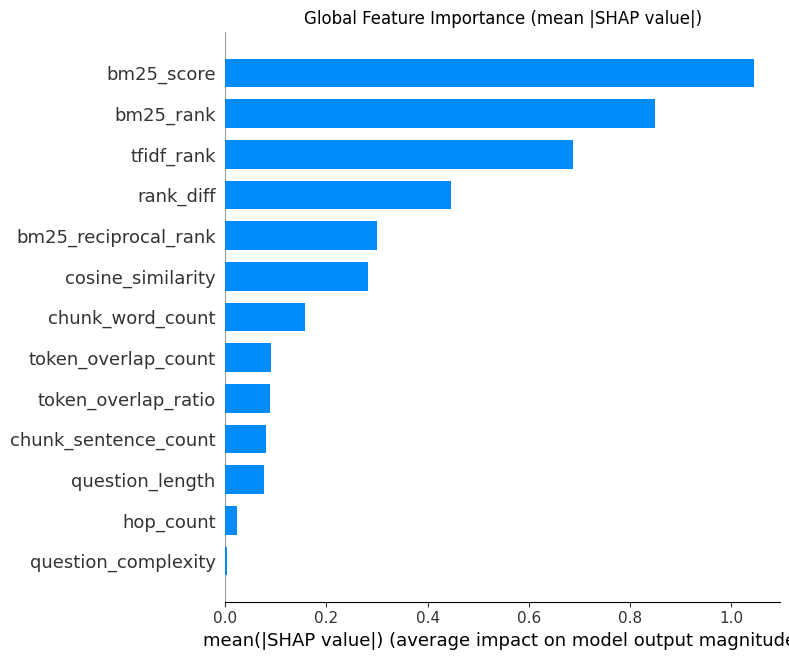

In [73]:
#global explanation
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, plot_type="bar", show=False)
plt.title("Global Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

C:\Users\sidagarwal\AppData\Local\Temp\ipykernel_29792\2594980025.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)


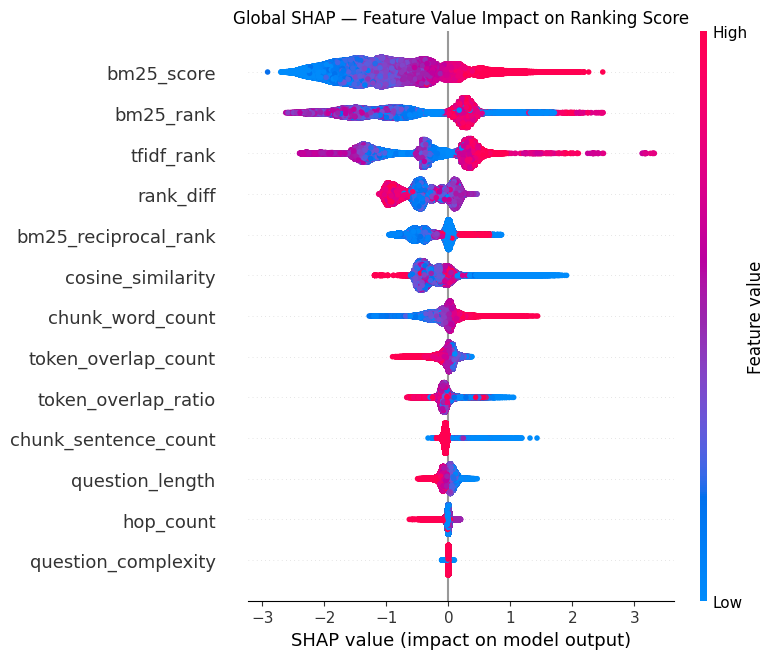

In [74]:
#global explanation SHAP value impact
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, show=False)
plt.title("Global SHAP — Feature Value Impact on Ranking Score")
plt.tight_layout()
plt.show()

In [75]:
#local explanation: pick a val question and explain its top candidate's score
sample_idx = 0  
sample_c = val_candidates[sample_idx]
sample_q_text = sample_c['metadata']['question']
n_cands = len(sample_c['candidate_ids'])

In [76]:
#get SHAP for this question's candidates
X_local = sample_c['features']
shap_local = explainer.shap_values(X_local)

In [77]:
#rank candidates by model score
scores_local = xgb_model.predict(X_local)
rank_order = np.argsort(scores_local)[::-1]

In [78]:
print(f"Question: {sample_q_text[:100]}...")
print(f"Golden IDs: {sample_c['golden_ids']}")
print(f"Candidates: {n_cands}, Model top-5 IDs: {[sample_c['candidate_ids'][i] for i in rank_order[:5]]}")
print(f"Golden in top-5: {set(sample_c['candidate_ids'][i] for i in rank_order[:5]) & sample_c['golden_ids']}")

Question: How does the chemical tunability of metal-organic frameworks (MOFs) enable the identification of opt...
Golden IDs: {96448, 96450, 96452, 96447}
Candidates: 138, Model top-5 IDs: [96443, 96469, 96447, 96449, 96442]
Golden in top-5: {96447}


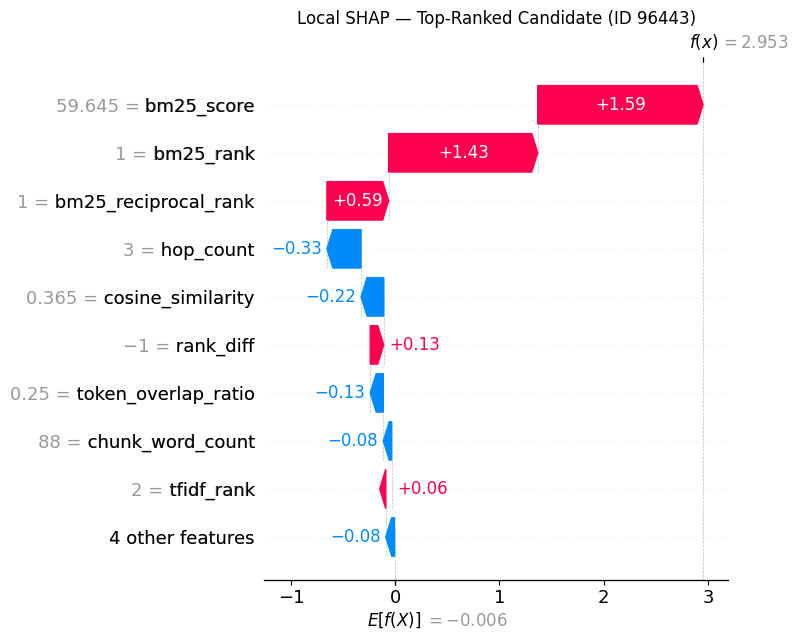

In [79]:
#waterfall: why was the #1 ranked candidate scored highest?
top_idx = rank_order[0]
shap.waterfall_plot(shap.Explanation(
    values=shap_local[top_idx],
    base_values=explainer.expected_value,
    data=X_local[top_idx],
    feature_names=feature_cols
), show=False)
plt.title(f"Local SHAP — Top-Ranked Candidate (ID {sample_c['candidate_ids'][top_idx]})")
plt.tight_layout()
plt.show()

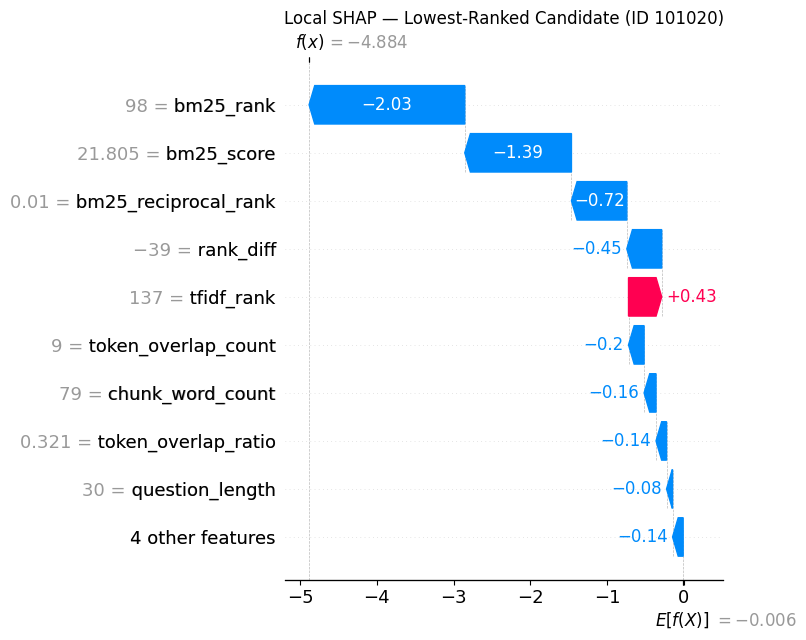

In [80]:
#compare top rank vs lowest rank candidate
low_idx = rank_order[-1]
shap.waterfall_plot(shap.Explanation(
    values=shap_local[low_idx],
    base_values=explainer.expected_value,
    data=X_local[low_idx],
    feature_names=feature_cols
), show=False)
plt.title(f"Local SHAP — Lowest-Ranked Candidate (ID {sample_c['candidate_ids'][low_idx]})")
plt.tight_layout()
plt.show()

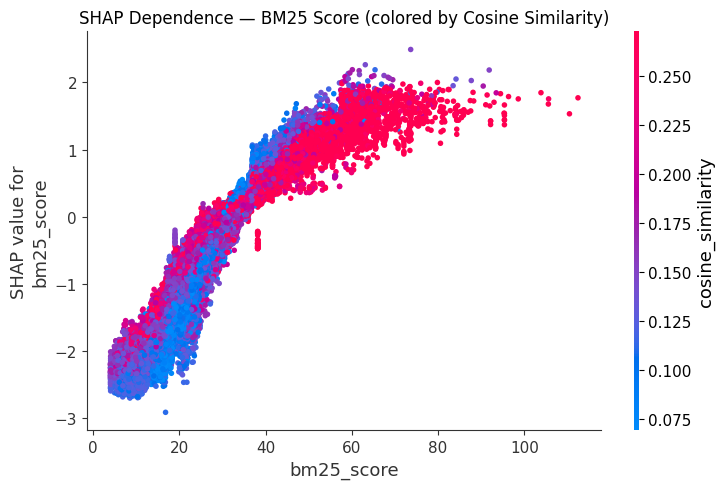

In [83]:
#SHAP dependence
shap.dependence_plot("bm25_score", shap_values, X_shap,
                     feature_names=feature_cols,
                     interaction_index="cosine_similarity", show=False)
plt.title("SHAP Dependence — BM25 Score (colored by Cosine Similarity)")
plt.tight_layout()
plt.show()

In [81]:
# SHAP comparison: golden chunk vs model's top pick (when they disagree)
compare_c = None
for c in val_candidates[:500]:
    scores = xgb_model.predict(c['features'])
    top_pick = c['candidate_ids'][np.argmax(scores)]
    if top_pick not in c['golden_ids'] and len(c['golden_ids'] & set(c['candidate_ids'])) > 0:
        compare_c = c
        break

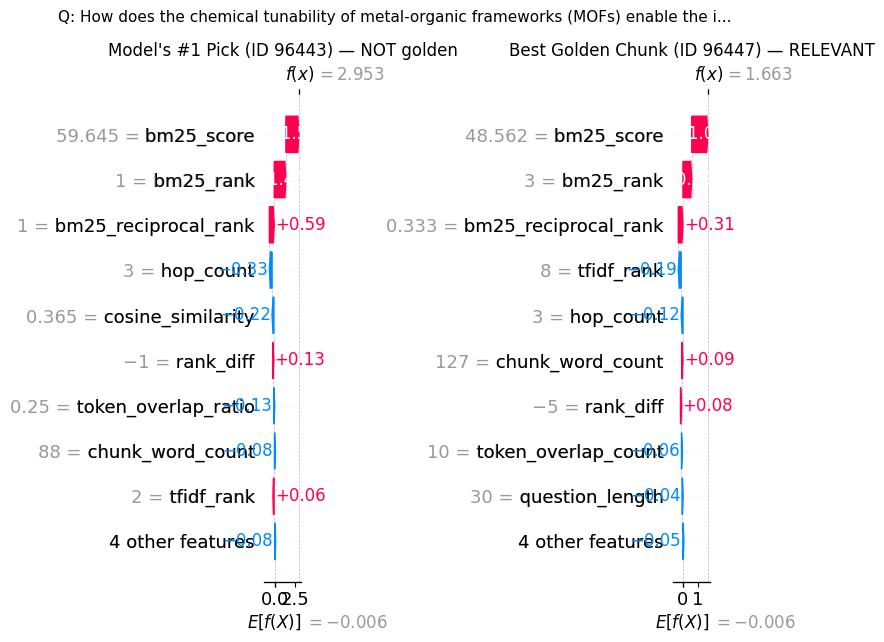


Feature comparison:
Feature                     Model #1     Golden       Diff
-------------------------------------------------------
question_complexity           5.0000     5.0000    +0.0000
hop_count                     3.0000     3.0000    +0.0000
chunk_word_count             88.0000   127.0000   -39.0000
chunk_sentence_count          5.0000     5.0000    +0.0000
bm25_score                   59.6451    48.5616   +11.0835
cosine_similarity             0.3645     0.2575    +0.1070
token_overlap_ratio           0.2500     0.3571    -0.1071
token_overlap_count           7.0000    10.0000    -3.0000
question_length              30.0000    30.0000    +0.0000
bm25_rank                     1.0000     3.0000    -2.0000
tfidf_rank                    2.0000     8.0000    -6.0000
bm25_reciprocal_rank          1.0000     0.3333    +0.6667
rank_diff                    -1.0000    -5.0000    +4.0000


In [82]:
if compare_c:
    cids = compare_c['candidate_ids']
    golden_in_pool = [i for i, cid in enumerate(cids) if cid in compare_c['golden_ids']]
    scores_cmp = xgb_model.predict(compare_c['features'])
    top_model_idx = np.argmax(scores_cmp)

    # pick the highest-scored golden chunk
    golden_scores = [(i, scores_cmp[i]) for i in golden_in_pool]
    best_golden_idx = max(golden_scores, key=lambda x: x[1])[0]

    shap_cmp = explainer.shap_values(compare_c['features'])

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # left: model's top pick (wrong)
    plt.sca(axes[0])
    shap.waterfall_plot(shap.Explanation(
        values=shap_cmp[top_model_idx],
        base_values=explainer.expected_value,
        data=compare_c['features'][top_model_idx],
        feature_names=feature_cols
    ), show=False)
    axes[0].set_title(f"Model's #1 Pick (ID {cids[top_model_idx]}) — NOT golden")

    # right: best golden chunk
    plt.sca(axes[1])
    shap.waterfall_plot(shap.Explanation(
        values=shap_cmp[best_golden_idx],
        base_values=explainer.expected_value,
        data=compare_c['features'][best_golden_idx],
        feature_names=feature_cols
    ), show=False)
    axes[1].set_title(f"Best Golden Chunk (ID {cids[best_golden_idx]}) — RELEVANT")

    plt.suptitle(f"Q: {compare_c['metadata']['question'][:80]}...", fontsize=11)
    plt.tight_layout()
    plt.show()

    # print the feature difference
    print("\nFeature comparison:")
    print(f"{'Feature':<25} {'Model #1':>10} {'Golden':>10} {'Diff':>10}")
    print("-" * 55)
    for j, col in enumerate(feature_cols):
        v1 = compare_c['features'][top_model_idx][j]
        v2 = compare_c['features'][best_golden_idx][j]
        print(f"{col:<25} {v1:>10.4f} {v2:>10.4f} {v1-v2:>+10.4f}")
else:
    print("No disagreement found in first 500 val questions")

## Findings
- **XGBoost Ranker achieved the best test NDCG@10 of 0.5308**, Outperforming the BM25 baseline (0.5227) and all other models. LightGBM and Random Forest performed comparably on validation.
- **BM25 is a strong baseline.** The model only improved over BM25 by ~1.5%, **Performance varies by query type.** Multi-hop queries (NDCG@10=0.549) outperformed contextual queries (0.510). Temporal reasoning was weakest (0.494).
- **Top features by SHAP importance: `cosine_similarity`, `bm25_score`, `bm25_reciprocal_rank`, and `tfidf_rank`.** Rank-based features (`bm25_rank`, `tfidf_rank`, `rank_diff`) added meaningful signal beyond raw scores.
- **Candidate pool recall caps model performance.** Only 75.7% of golden chunks appear in the BM25∪TF-IDF top-100 pool on test.
- **Query type and reasoning type features had negligible importance** (<1%) and were dropped.

## Next Steps
- **Dense retrieval.** Replace or augment BM25/TF-IDF with embedding-based retrieval (e.g., OpenAI, Cohere, or sentence-transformers) to improve candidate pool recall beyond 75.7%.
- **Cross-encoder re-ranking.** Use a transformer cross-encoder (e.g., `ms-marco-MiniLM`) as the final re-ranker instead of tree-based models.- **Train on full data.** Training on all 84k questions (instead of the 10k subsample) to improve model coverage.
- **Expand candidate pool.** Increase `candidate_k` or add a third retrieval method to capture more golden chunks in the pool.- 